# Logistic regression

### A straight line that outputs a probability

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | Why linear regression cannot do classification, what the sigmoid fixes, how to train it by gradient descent, and how it behaves on seven unbalanced classes |
| **You should already know** | [Linear regression](../../02-regression/01-linear-regression/) |
| **Datasets** | Breast Cancer Wisconsin (569 × 30), UCI Dry Bean (13,611 × 16) |
| **Runtime** | About a minute on a laptop CPU |
| **Next** | [03-02 k-Nearest Neighbours](../02-k-nearest-neighbours/) |

---

## 1. The idea

Linear regression predicts any number at all: -4, 0.3, 812. For a yes-or-no
question that is useless. You want a probability, which has to live between 0
and 1.

Logistic regression keeps the weighted sum from linear regression and squashes
the result through a function that cannot leave that range:

$$\sigma(z) = \frac{1}{1 + e^{-z}} \qquad \text{where} \quad z = w \cdot x + b$$

That is the entire difference. Same weighted sum, one squash on the end. The
name is unfortunate: it does classification, not regression.

In [1]:
import sys
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import datasets, style

style.use()
FIG = pathlib.Path("figures")
SEED = 0

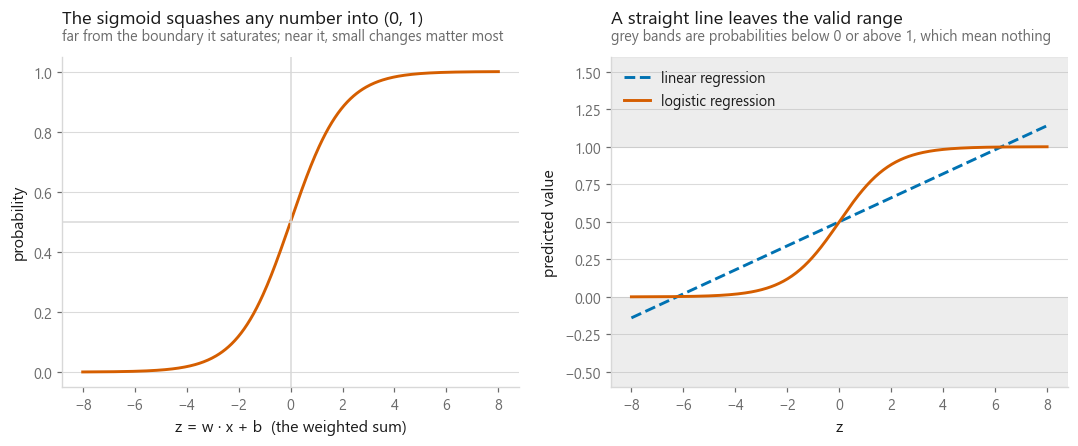

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(11.8, 3.9))

z = np.linspace(-8, 8, 400)
axes[0].plot(z, 1 / (1 + np.exp(-z)), color=style.HIGHLIGHT)
axes[0].axhline(0.5, color=style.RULE, lw=1)
axes[0].axvline(0, color=style.RULE, lw=1)
axes[0].set_xlabel("z = w · x + b  (the weighted sum)")
axes[0].set_ylabel("probability")
style.title(axes[0], "The sigmoid squashes any number into (0, 1)",
            "far from the boundary it saturates; near it, small changes matter most")

# Why not just use linear regression for a yes/no target?
axes[1].plot(z, 0.5 + 0.08 * z, color=style.PALETTE[0], ls="--", label="linear regression")
axes[1].plot(z, 1 / (1 + np.exp(-z)), color=style.HIGHLIGHT, label="logistic regression")
axes[1].axhspan(1.0, 1.6, color=style.NEUTRAL, alpha=0.22)
axes[1].axhspan(-0.6, 0.0, color=style.NEUTRAL, alpha=0.22)
axes[1].set_ylim(-0.6, 1.6)
axes[1].set_xlabel("z")
axes[1].set_ylabel("predicted value")
axes[1].legend(loc="upper left")
style.title(axes[1], "A straight line leaves the valid range",
            "grey bands are probabilities below 0 or above 1, which mean nothing")

style.save(fig, FIG / "fig-01-sigmoid.png")

## 2. The maths

For linear regression we minimised squared error. Here squared error is a bad
choice: paired with the sigmoid it produces a cost surface with local minima,
so gradient descent can get stuck. Instead we use **log loss**, also called
binary cross-entropy:

$$J(w) = -\frac{1}{m}\sum_{i=1}^{m} \Big[ y_i \log(\hat{p}_i) + (1-y_i)\log(1-\hat{p}_i) \Big]$$

Read it one case at a time. If the true label is 1, only the first term
survives, and it is $-\log(\hat{p})$: nearly zero when you predicted 0.99, and
enormous when you predicted 0.01. Confident and wrong is punished far harder
than uncertain and wrong, which is the behaviour you want.

Differentiate it and something pleasing happens. The gradient is:

$$\frac{\partial J}{\partial w} = \frac{1}{m} X^\top (\hat{p} - y)$$

Identical in form to linear regression's gradient. **Prediction minus truth,
weighted by the inputs.** There is no closed-form solution like the normal
equation, so we iterate.

## 3. From scratch

In [3]:
class LogisticRegressionScratch:
    """Binary logistic regression trained by batch gradient descent."""

    def __init__(self, learning_rate=0.5, n_steps=2000):
        self.learning_rate = learning_rate
        self.n_steps = n_steps
        self.history_ = []

    @staticmethod
    def _sigmoid(z):
        # Clip before exponentiating. Without this, z = -800 overflows to inf
        # and the loss becomes nan. This is the single most common bug in
        # hand-written logistic regression.
        return 1.0 / (1.0 + np.exp(-np.clip(z, -250, 250)))

    def fit(self, X, y):
        X, y = np.asarray(X, float), np.asarray(y, float)
        m, n = X.shape
        self.coef_, self.intercept_ = np.zeros(n), 0.0

        for _ in range(self.n_steps):
            p = self._sigmoid(X @ self.coef_ + self.intercept_)
            error = p - y                          # the whole gradient, in one line

            self.coef_ -= self.learning_rate * (X.T @ error) / m
            self.intercept_ -= self.learning_rate * error.mean()

            # 1e-12 keeps log(0) from becoming -inf on a perfectly confident call
            self.history_.append(
                -np.mean(y * np.log(p + 1e-12) + (1 - y) * np.log(1 - p + 1e-12)))
        return self

    def predict_proba(self, X):
        return self._sigmoid(np.asarray(X, float) @ self.coef_ + self.intercept_)

    def predict(self, X):
        return (self.predict_proba(X) >= 0.5).astype(int)


from sklearn.preprocessing import StandardScaler

X_bc, y_bc = datasets.breast_cancer()
X_scaled = StandardScaler().fit_transform(X_bc)

mine = LogisticRegressionScratch().fit(X_scaled, y_bc)
print(f"final log loss   : {mine.history_[-1]:.4f}")
print(f"training accuracy: {(mine.predict(X_scaled) == y_bc).mean():.4f}")

final log loss   : 0.0458
training accuracy: 0.9877


our accuracy      : 0.9877
sklearn accuracy  : 1.0000
predictions agree : 0.9877


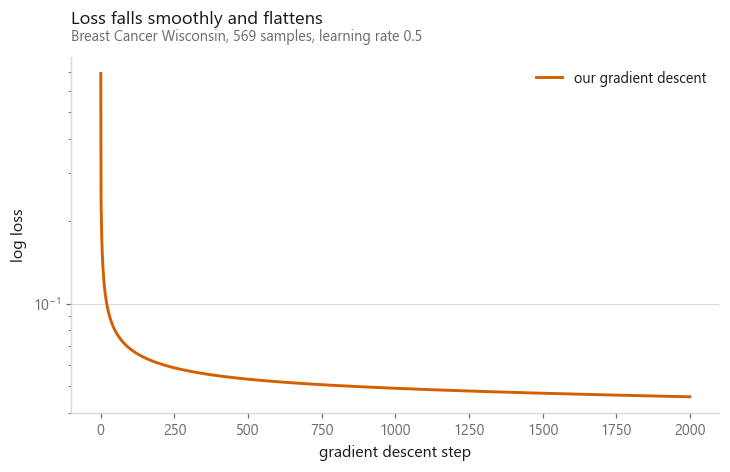

In [4]:
from sklearn.linear_model import LogisticRegression

# C is inverse regularisation strength. sklearn always regularises by default,
# so a huge C is needed to compare like with like against our unpenalised version.
theirs = LogisticRegression(C=1e6, max_iter=5000).fit(X_scaled, y_bc)

fig, ax = plt.subplots(figsize=(7.6, 4.2))
ax.plot(mine.history_, color=style.HIGHLIGHT, label="our gradient descent")
ax.axhline(0.0, color=style.RULE, lw=1)
ax.set_xlabel("gradient descent step")
ax.set_ylabel("log loss")
ax.set_yscale("log")
ax.legend()
style.title(ax, "Loss falls smoothly and flattens",
            "Breast Cancer Wisconsin, 569 samples, learning rate 0.5")
style.save(fig, FIG / "fig-02-training-loss.png")

agreement = (mine.predict(X_scaled) == theirs.predict(X_scaled)).mean()
print(f"our accuracy      : {(mine.predict(X_scaled) == y_bc).mean():.4f}")
print(f"sklearn accuracy  : {theirs.score(X_scaled, y_bc):.4f}")
print(f"predictions agree : {agreement:.4f}")

They do **not** land in the same place, and the gap is more instructive than
agreement would have been. Ours reaches 98.8% training accuracy; scikit-learn
reaches 100%.

This dataset is **linearly separable**: some straight line divides the two
classes perfectly. For separable data with regularisation switched off
(`C=1e6`), the mathematically optimal weights are *infinite*: the loss keeps
falling as the weights grow and the sigmoid saturates toward hard 0 and 1.
L-BFGS is an aggressive optimiser and chases that a long way in its iterations.
Two thousand steps of plain gradient descent do not get as far. Same model, same
objective, different distance travelled toward a target at infinity.

Neither number is something to celebrate. 100% training accuracy on separable
data means the model has been driven to maximum confidence on every single
point, which is precisely what regularisation exists to prevent. Leave `C` at
its default of 1.0 and scikit-learn deliberately stops short. And both are
*training* accuracies, measured on data the model just memorised. The
cross-validated numbers in the next section are the ones that mean anything.

## 4. In practice: seven classes, unevenly sized

Binary is the easy case. The Dry Bean dataset has **seven varieties of bean**
measured from photographs, and the classes are far from balanced, 522 Bombay
against 3,546 Dermason. That imbalance is the interesting part.

Logistic regression extends to many classes through the **softmax**, which is
the sigmoid's multi-class cousin: score every class, exponentiate, divide by the
total so the scores sum to 1.

In [5]:
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.pipeline import make_pipeline

X_bean, y_bean = datasets.dry_bean()
folds = StratifiedKFold(5, shuffle=True, random_state=SEED)

model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000))
predicted = cross_val_predict(model, X_bean, y_bean, cv=folds)

from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report

print(f"accuracy          : {accuracy_score(y_bean, predicted):.4f}")
print(f"balanced accuracy : {balanced_accuracy_score(y_bean, predicted):.4f}\n")
print(classification_report(y_bean, predicted, digits=3))

accuracy          : 0.9235
balanced accuracy : 0.9343



              precision    recall  f1-score   support

    BARBUNYA      0.943     0.905     0.924      1322
      BOMBAY      1.000     1.000     1.000       522
        CALI      0.932     0.944     0.938      1630
    DERMASON      0.923     0.915     0.919      3546
       HOROZ      0.954     0.952     0.953      1928
       SEKER      0.947     0.947     0.947      2027
        SIRA      0.856     0.877     0.867      2636

    accuracy                          0.924     13611
   macro avg      0.936     0.934     0.935     13611
weighted avg      0.924     0.924     0.924     13611



### Read the two accuracies against each other

Plain accuracy counts every bean equally, so the 3,546 Dermason dominate it.
Balanced accuracy averages the recall of each class, so tiny Bombay counts as
much as huge Dermason.

Here **balanced accuracy is the higher of the two**, at 0.934 against 0.924, and
that is worth pausing on because it is the opposite of the usual worry. The
standard fear with unbalanced classes is that the rare ones get trampled. On
this dataset the rare class is the *easiest*: Bombay has only 522 examples and
is recalled perfectly, because Bombay beans are enormous and nothing else looks
like them. The hardest variety is Sira, which is one of the most common.

**Class size and class difficulty are different things.** Check, do not assume.

The confusion matrix shows where the mistakes actually go.

recall by variety, worst first:
SIRA        0.877
BARBUNYA    0.905
DERMASON    0.915
CALI        0.944
SEKER       0.947
HOROZ       0.952
BOMBAY      1.000

most mutually confused pair: DERMASON and SIRA (combined confusion 0.153)


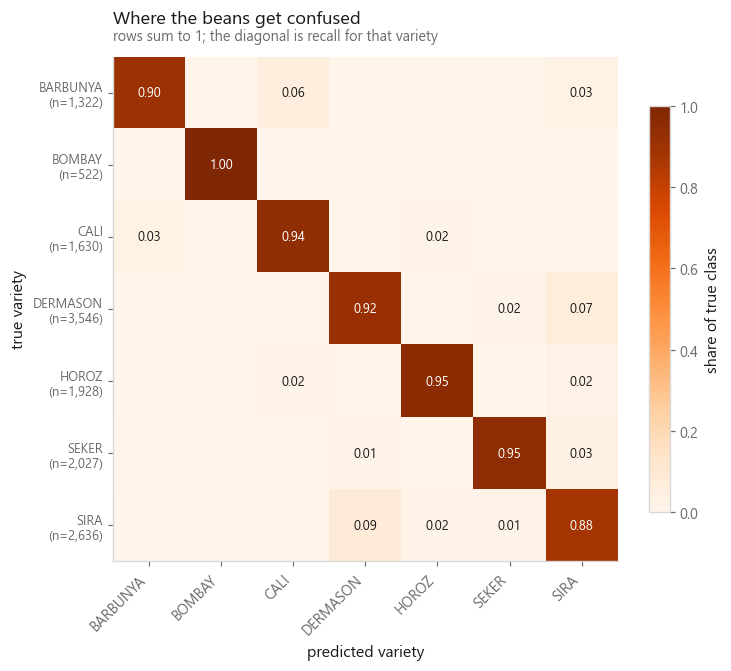

In [6]:
from sklearn.metrics import confusion_matrix

labels = sorted(y_bean.unique())
matrix = confusion_matrix(y_bean, predicted, labels=labels, normalize="true")

fig, ax = plt.subplots(figsize=(7.4, 6.0))
image = ax.imshow(matrix, cmap="Oranges", vmin=0, vmax=1)

for i in range(len(labels)):
    for j in range(len(labels)):
        if matrix[i, j] >= 0.01:
            ax.text(j, i, f"{matrix[i, j]:.2f}", ha="center", va="center",
                    fontsize=8.5, color="white" if matrix[i, j] > 0.55 else style.INK)

counts = y_bean.value_counts()
ax.set_xticks(range(len(labels)), labels, rotation=45, ha="right")
ax.set_yticks(range(len(labels)), [f"{l}\n(n={counts[l]:,})" for l in labels], fontsize=8.5)
ax.set_xlabel("predicted variety")
ax.set_ylabel("true variety")
ax.grid(False)
fig.colorbar(image, ax=ax, shrink=0.8, label="share of true class")
style.title(ax, "Where the beans get confused",
            "rows sum to 1; the diagonal is recall for that variety")
style.save(fig, FIG / "fig-03-confusion.png")

worst = pd.Series(matrix.diagonal(), index=labels).sort_values()
print("recall by variety, worst first:")
print(worst.round(3).to_string())

# The two classes with the lowest recall are not necessarily confused with each
# OTHER -- each may simply be hard on its own. To find the genuinely confused
# pair, add the matrix to its transpose so both directions count, and take the
# largest off-diagonal entry.
mutual = matrix + matrix.T
np.fill_diagonal(mutual, 0)
i, j = np.unravel_index(np.argmax(mutual), mutual.shape)
pair = [labels[i], labels[j]]
print(f"\nmost mutually confused pair: {pair[0]} and {pair[1]} "
      f"(combined confusion {mutual[i, j]:.3f})")

## 5. When it wins, when it loses

The confusion matrix says the errors are not spread evenly, and one pair
dominates. Note that finding that pair takes a little care: the two varieties
with the *lowest recall* are not automatically confused with each other, since
each might be losing beans to a different neighbour. Adding the matrix to its
transpose and taking the largest off-diagonal entry finds the pair that actually
trade beans in both directions.

Logistic regression can only draw **straight boundaries**, so the natural
suspicion is that a straight line is simply the wrong shape for this pair. The
chart below takes the genuinely confused pair, squashes them to two dimensions
so the boundary can be drawn on paper, and puts that suspicion to the test.

separating DERMASON from SIRA on two components: accuracy 0.910
beans involved: 6,182


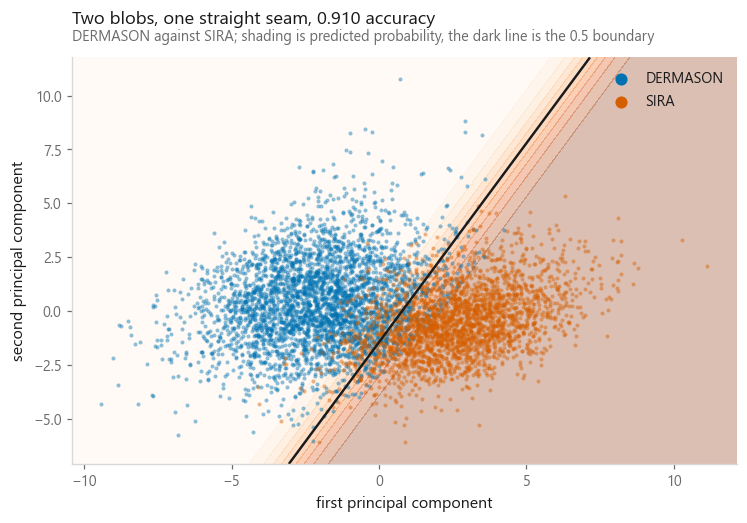

In [7]:
from sklearn.decomposition import PCA

mask = y_bean.isin(pair).values
X_pair = StandardScaler().fit_transform(X_bean[mask])
y_pair = (y_bean[mask] == pair[1]).astype(int).values

# Two PCA components so the boundary can actually be drawn on paper.
flat = PCA(n_components=2, random_state=SEED).fit_transform(X_pair)
boundary_model = LogisticRegression(max_iter=3000).fit(flat, y_pair)
pair_accuracy = boundary_model.score(flat, y_pair)

step = 0.02
xx, yy = np.meshgrid(np.arange(flat[:, 0].min() - 1, flat[:, 0].max() + 1, step),
                     np.arange(flat[:, 1].min() - 1, flat[:, 1].max() + 1, step))
zz = boundary_model.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1].reshape(xx.shape)

fig, ax = plt.subplots(figsize=(7.8, 4.8))
ax.contourf(xx, yy, zz, levels=np.linspace(0, 1, 11), cmap="Oranges", alpha=0.30)
ax.contour(xx, yy, zz, levels=[0.5], colors=[style.INK], linewidths=1.6)
for value, name, colour in [(0, pair[0], style.PALETTE[0]), (1, pair[1], style.HIGHLIGHT)]:
    sel = y_pair == value
    ax.scatter(flat[sel, 0], flat[sel, 1], s=7, alpha=0.45, c=colour, linewidths=0, label=name)
ax.set_xlabel("first principal component")
ax.set_ylabel("second principal component")
ax.grid(False)
legend = ax.legend(loc="upper right", markerscale=3)
for handle in legend.legend_handles:
    handle.set_alpha(1)
style.title(ax,
            f"Two blobs, one straight seam, {pair_accuracy:.3f} accuracy",
            f"{pair[0]} against {pair[1]}; shading is predicted probability, "
            "the dark line is the 0.5 boundary")
style.save(fig, FIG / "fig-04-decision-boundary.png")

print(f"separating {pair[0]} from {pair[1]} on two components: "
      f"accuracy {pair_accuracy:.3f}")
print(f"beans involved: {mask.sum():,}")

**The suspicion does not survive the picture.** The two clouds are ordinary
ellipsoidal blobs, the gap between them is a straight diagonal band, and the
fitted boundary runs along the middle of that band. There is no curved seam
here for a straight line to fail against. The line is in the right place.

What it runs into is **overlap**. On these two components the pair separates at
only 0.910, and the beans the model gets wrong sit almost entirely inside the
band. DERMASON and SIRA of that size and shape are not distinguishable from these
sixteen measurements, by any boundary of any shape.

The distinction matters because the two failures ask for different repairs. A
curved seam asks for a model that bends. Overlap asks for a measurement that
separates the varieties in the first place, and no amount of flexibility
recovers information the columns never recorded.

That second point is worth testing rather than assuming, and this chapter has
already half-tested it. [Random forests](../../04-ensembles/02-random-forest/)
reach 0.924 accuracy on the full seven-class problem against logistic
regression's 0.9235, a tie. Bean measurements are smooth geometric quantities
with little non-linear structure to exploit, so the model that bends has
nothing to bend around. A more flexible model is not automatically a better
one, which is a theme this book returns to repeatedly.

## Cheat sheet

| | |
|---|---|
| **Use it when** | You want a fast, calibrated, explainable baseline; classes are roughly linearly separable; you need to defend the model to somebody |
| **Avoid it when** | The boundary is curved; features interact strongly; you have far more columns than rows and no regularisation |
| **Outputs** | Genuine probabilities, and usually well calibrated out of the box, unusual and valuable |
| **Scaling needed** | Yes. The default L2 penalty punishes large weights, so unscaled features are penalised unfairly |
| **Main dials** | `C` (inverse regularisation strength), `penalty` (l1, l2, elasticnet), `class_weight` |
| **Watch out** | scikit-learn regularises by default. `LogisticRegression()` is not the textbook model; `C=1e6` is |
| **Next** | [k-NN](../02-k-nearest-neighbours/) for a non-linear boundary with no training at all |

## What to remember

1. Logistic regression is linear regression plus a sigmoid, trained with log
   loss instead of squared error.
2. The gradient is $X^\top(\hat{p} - y)/m$, prediction minus truth, exactly as
   in linear regression.
3. Clip before you exponentiate, or your loss becomes `nan`.
4. Compare accuracy against balanced accuracy, but do not assume which way the
   gap will run. Here balanced accuracy is the higher of the two, because the
   rarest variety is also the easiest one. Class size and class difficulty are
   different things.
5. The decision boundary is a straight line, which is not always the thing
   that is failing. Look at the picture before blaming the shape: a curved
   seam and two overlapping clouds cost the same accuracy and need opposite
   repairs.

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [03-02 k-Nearest Neighbours](../02-k-nearest-neighbours/) ·
Back to [the curriculum](../../CURRICULUM.md)

`#MachineLearning` `#LogisticRegression` `#Classification` `#Python` `#ScikitLearn`
`#DataScience` `#MLTutorial` `#Softmax` `#GradientDescent` `#LearnMachineLearning`